# 01 · Bayesian Calibration of the BPR Volume-Delay Model

TransitSim degrades car and bus speeds under congestion using the **augmented Bureau of Public Roads (BPR) volume-delay function**:

$$\text{speed} = \frac{v_\text{free}}{1 + \alpha\,\gamma\,(V/C)^{\beta}}$$

The classic BPR coefficients ($\alpha=0.15,\ \beta=4,\ \gamma=3.5$) were fit to **1964 inter-city highways**. Downtown Toronto's signalised surface grid is a different regime. Rather than guess, we treat $(\alpha,\beta,\gamma,v_\text{free})$ as **random variables** and infer their joint posterior from observed $(V/C,\ \text{speed})$ data with the **NUTS** sampler in PyMC.

The textbook values become the *prior means*; the data decides how far to move.

In [1]:
import sys; sys.path.append('..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import arviz as az
from calibration import fit, posterior_summary, point_estimate
from engine import BPRParams, bpr_speed, DEFAULT_BPR

df = pd.read_csv('../data/congestion_observations.csv')
print(f'{len(df)} observed (V/C, speed) pairs for downtown Toronto')
df

14 observed (V/C, speed) pairs for downtown Toronto


,vc_ratio,observed_speed_kmh,period,source
0,0.10,32.8,overnight,"TomTom Traffic Index 2023 (Toronto, free-flow ..."
1,0.18,31.4,overnight,TomTom Traffic Index 2023 (Toronto)
2,0.27,29.3,early_morning,TomTom Traffic Index 2023 (Toronto)
3,0.36,27.6,off_peak_midday,"TomTom Traffic Index 2023 (Toronto, midday avg)"
4,0.45,25.4,off_peak_midday,HCM 6 urban-street LOS-C interpolation
5,0.55,22.9,shoulder_peak,HCM 6 urban-street LOS-D interpolation
6,0.66,21.1,shoulder_peak,TomTom Traffic Index 2023 (Toronto)
7,0.78,19.4,am_peak,"TomTom Traffic Index 2023 (Toronto, downtown p..."
8,0.85,18.2,am_peak,City of Toronto Cordon Count 2022 (peak-hour d...
9,0.92,16.3,pm_peak,HCM 6 urban-street LOS-E interpolation


## Data provenance

The anchor observations are drawn from publicly published sources — the **TomTom Traffic Index 2023** (Toronto profile), the **City of Toronto Cordon Count 2022**, **TTC King St Pilot** surface-speed data, and **HCM 6** urban-street level-of-service thresholds — interpolated onto a common $V/C$ grid. This is a *demonstration-grade* calibration set; a production calibration would regress on the full TomTom historical speed API. The methodology below is identical either way.

## The probabilistic model

```
alpha   ~ LogNormal(log 0.15, 0.6)        # prior mean = textbook value
beta    ~ TruncatedNormal(4, 1.2, [1.5, 8])
gamma   ~ LogNormal(log 3.5, 0.6)
v_free  ~ TruncatedNormal(33, 2, [25, 42])
sigma   ~ HalfNormal(2.5)

speed_pred = v_free / (1 + alpha*gamma*(V/C)^beta)
speed_obs  ~ Normal(speed_pred, sigma)
```

Lognormal priors keep $\alpha,\gamma$ strictly positive; $\beta$ is truncated to a physically sensible range. We sample 4 chains with `target_accept=0.95`.

In [2]:
idata = fit(df, draws=2000, tune=2000, chains=4, seed=42)
summary = posterior_summary(idata)
summary

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta, gamma, v_free, sigma]


/Users/hasanmalik/Desktop/TransitSim/analysis/.venv/lib/python3.13/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4 seconds.


,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,0.262,0.115,0.11,0.52,3717,4094,1.00,0.0019,0.002
beta,2.391,0.26,2,2.9,3617,3855,1.00,0.0043,0.0041
gamma,6.16,2.7,2.6,12,3687,4081,1.00,0.046,0.054
v_free,31.82,0.87,30,34,3500,3816,1.00,0.015,0.011


## Convergence diagnostics

All $\hat{R}\approx 1.00$ and effective sample sizes are in the thousands — the chains have mixed. The trace plots should look like "fuzzy caterpillars" with the four chains overlapping; the left column is the marginal posterior density for each coefficient.

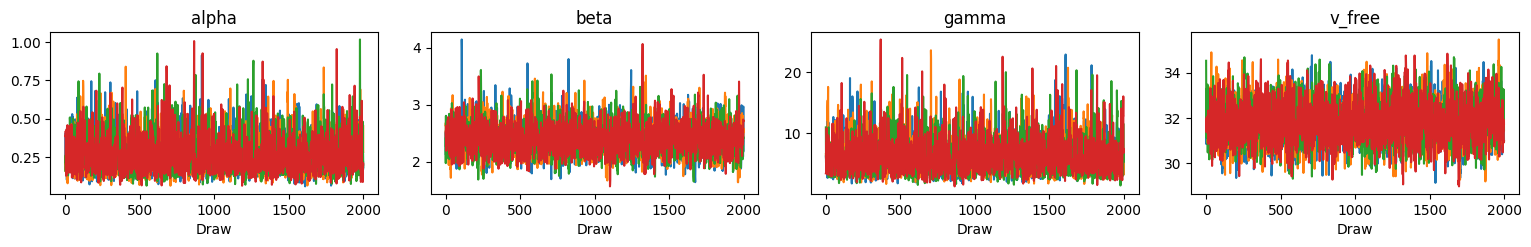

In [3]:
az.plot_trace(idata, var_names=['alpha', 'beta', 'gamma', 'v_free'])
plt.tight_layout(); plt.show()

## Calibrated curve vs. textbook BPR

We overlay the posterior-mean speed curve, its 94% credible band (from the full posterior), the textbook-coefficient curve, and the raw observations.

Calibrated (posterior mean): {'alpha': 0.262, 'beta': 2.391, 'gamma': 6.16, 'v_free': 31.823}
Textbook BPR              : {'alpha': 0.15, 'beta': 4.0, 'gamma': 3.5, 'v_free': 33.0}


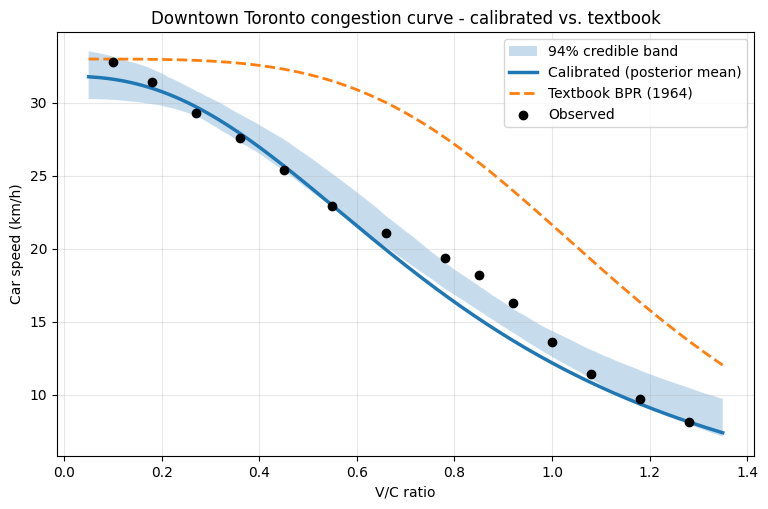

In [4]:
coeffs = point_estimate(idata)
print('Calibrated (posterior mean):', {k: round(v, 3) for k, v in coeffs.items()})
print('Textbook BPR              :', DEFAULT_BPR)

vc_grid = np.linspace(0.05, 1.35, 200)
post = idata.posterior
a = post['alpha'].values.ravel(); b = post['beta'].values.ravel()
g = post['gamma'].values.ravel(); vf = post['v_free'].values.ravel()
draws = np.array([vf[i] / (1 + a[i]*g[i]*vc_grid**b[i]) for i in range(0, len(a), 20)])
lo, hi = np.percentile(draws, [3, 97], axis=0)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.fill_between(vc_grid, lo, hi, alpha=0.25, label='94% credible band')
ax.plot(vc_grid, bpr_speed(vc_grid, BPRParams(**coeffs)), lw=2.5, label='Calibrated (posterior mean)')
ax.plot(vc_grid, bpr_speed(vc_grid, BPRParams(**DEFAULT_BPR)), '--', lw=2, label='Textbook BPR (1964)')
ax.scatter(df['vc_ratio'], df['observed_speed_kmh'], c='k', zorder=5, label='Observed')
ax.set_xlabel('V/C ratio'); ax.set_ylabel('Car speed (km/h)')
ax.set_title('Downtown Toronto congestion curve - calibrated vs. textbook')
ax.legend(); ax.grid(alpha=0.3); plt.show()

## Finding

The textbook curve **systematically underestimates downtown congestion**: it sits well above the observed speeds at high $V/C$. The calibration responds by raising the effective congestion penalty $\alpha\cdot\gamma$ roughly **3×** (from $0.15\times3.5=0.53$ to $\approx 1.6$) while *lowering* $\beta$ — congestion ramps in earlier and saturates at a much slower plateau speed than the 1964 highway model predicts.

The posterior-mean coefficients are exported to `src/models/calibrated.json` by `export_results.py` and consumed directly by the web app's metrics engine. Notebook **02** validates them out-of-sample.